# Observation-Blocking sanity-check walkthrough

The bandit is rewarded for occluding the guard's view of an Earth surface target. The reward mirrors the KSP-DG-aligned Sun-Blocking formulation — an *angular factor* `-û_BG·û_BT` (the bandit interposes when this is positive — guard and target are on opposite sides of the bandit) multiplied by a *range factor* `exp(-decay·(d_BG - d_target)²)` that places peak/trough lobes around `target_viewing_distance_m`. Crucially, the whole reward is gated to zero whenever the target is below `min_elevation_deg` from the guard — there is no observation to block when the target is already over the guard's horizon.

This notebook builds the scenario, runs a rollout, renders the trajectory, plots the rollout-time diagnostic (with the visibility gate shaded), and renders the 2D bandit-position reward surface at two different epochs so the visibility gate's effect on the surface is easy to see.

For framework deep-dive see `examples/workflow_3d_rtn.ipynb`. For the reward formula and knob reference see `docs/games/observation-blocking.md`.

**Note on target choice:** The `make_observation_blocking` defaults use a Northern-California target (37.4°N, -122.2°W), but the project default reference orbit is equatorial (in the ECI x-y plane). The default target is therefore never observable from the default orbit. This notebook overrides the target to (0°, 0°) — equatorial — so the visibility gate transitions during the rollout and the diagnostic actually demonstrates the gate behavior.

In [1]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from orbital_game import OrbitalGameEnv, rollout
from orbital_game.env.types import BySide
from orbital_game.games import make_observation_blocking
from orbital_game.policies import ZeroControl
from orbital_game.viz import (
    plot_observation_blocking_animated_diagnostic,
    plot_observation_blocking_diagnostic,
    plot_observation_blocking_position_sweep,
    plot_reward_diagnostic,
    plot_reward_position_sweep,
    plot_rollout_panels,
    plot_rollout_rewards,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build the scenario

`make_observation_blocking` takes the OB-specific knobs (`target_lat_deg`, `target_lon_deg`, `min_elevation_deg`, `target_viewing_distance_m`, `range_decay_coef`) plus the standard scenario knobs. The project-default IC sampler places the bandit far from `d_target`, so we override the bandit IC locally with `dataclasses.replace` to put the rollout inside the high-reward region. We also pin `epoch_mjd_utc` so the visibility timeline below is reproducible.

In [2]:
cfg = make_observation_blocking(
    target_lat_deg=0.0, target_lon_deg=0.0,
    min_elevation_deg=5.0,
    target_viewing_distance_m=500.0, range_decay_coef=4.0e-6,
    n_guards=1, n_bandits=1,
    dt=10.0, max_horizon_s=5400.0, seed=0,
    epoch_mjd_utc=60067.0,
)

# Override bandit IC locally so the rollout visits the high-reward region.
# (Project-default IC has the bandit too far from d_target.)
from dataclasses import replace
from orbital_game.sampling.side import RelativeEllipse
from orbital_game.sampling.spec import ICSpec

cfg = replace(
    cfg,
    ic_sampler=ICSpec(
        guard_sampler=RelativeEllipse(
            radial_ellipse_m=500.0, phase_rad=0.0, sigma_radial_ellipse_m=10.0,
        ),
        bandit_sampler=RelativeEllipse(
            radial_ellipse_m=600.0, phase_rad=jnp.pi / 4.0, sigma_radial_ellipse_m=10.0,
        ),
        validators=(),
        max_attempts=100,
    ),
)

print(f"max_steps:                  {cfg.max_steps}")
print(f"target lat/lon (deg):       ({cfg.game.target_lat_deg}, {cfg.game.target_lon_deg})")
print(f"min_elevation_deg:          {cfg.game.min_elevation_deg}")
print(f"target_viewing_distance_m:  {cfg.game.target_viewing_distance_m} m")
print(f"range_decay_coef:           {cfg.game.range_decay_coef}")
print(f"epoch_mjd_utc:              {cfg.epoch_mjd_utc}")
print(f"reference orbit:            {cfg.reference_orbit.position_eci[:3]} m")

max_steps:                  540
target lat/lon (deg):       (0.0, 0.0)
min_elevation_deg:          5.0
target_viewing_distance_m:  500.0 m
range_decay_coef:           4e-06
epoch_mjd_utc:              60067.0
reference orbit:            [7000000.       0.       0.] m


## 2. Construct env and run two rollouts (zero-control, two seeds)

In [3]:
env = OrbitalGameEnv(cfg)
guard_policy = ZeroControl(n_vehicles=cfg.n_guards, action_dim=3)
bandit_policy = ZeroControl(n_vehicles=cfg.n_bandits, action_dim=3)
init_ps = BySide(
    guard=lambda c, s, k: None,
    bandit=lambda c, s, k: None,
)
key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key1, n_steps=cfg.max_steps)
traj2 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key2, n_steps=cfg.max_steps)
print(f"rollout 1 bandit return:  {float(traj1.sides.bandit.reward.sum()):.4f}")
print(f"rollout 2 bandit return:  {float(traj2.sides.bandit.reward.sum()):.4f}")

rollout 1 bandit return:  -19.3343
rollout 2 bandit return:  -19.1710


## 3. Trajectory + reward over time

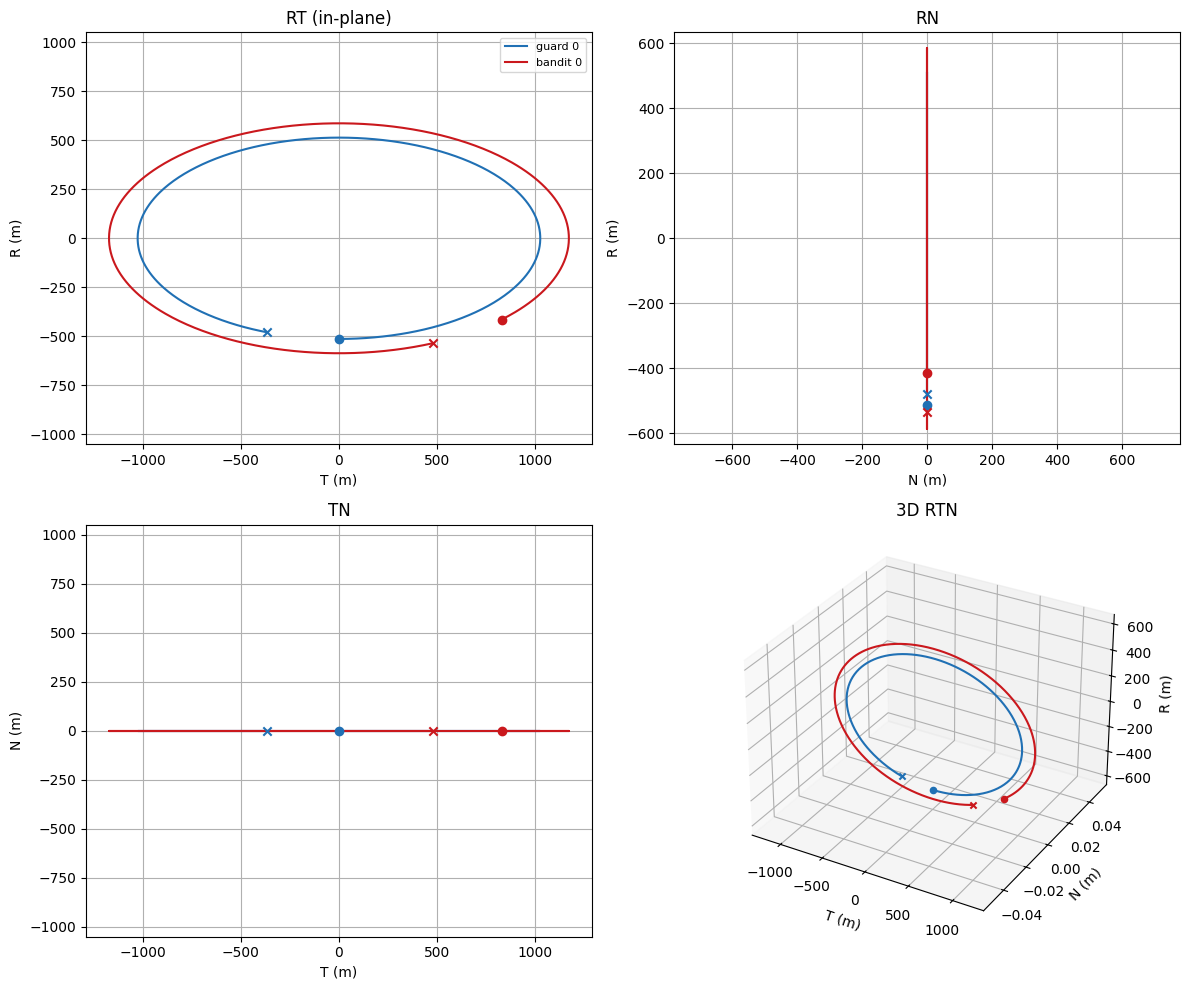

In [4]:
fig = plot_rollout_panels(traj1)
plt.show()

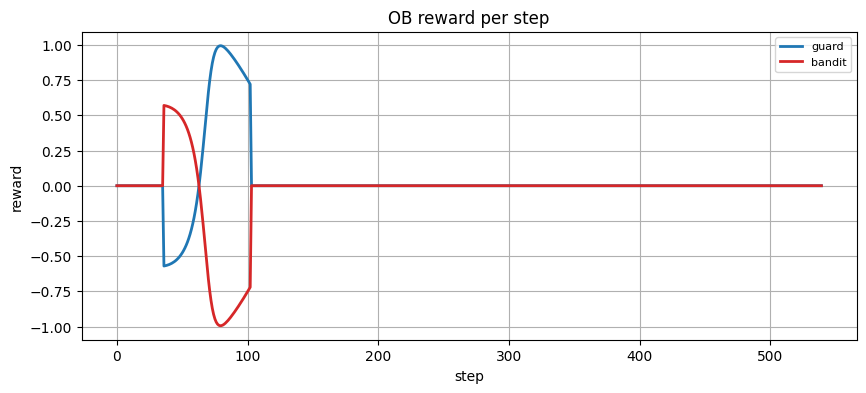

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_rollout_rewards(traj1, ax=ax)
ax.set_title("OB reward per step")
plt.show()

## 4. Game-specific rollout diagnostic

Four panels: target elevation from the guard with shaded windows when the target is below `min_elevation_deg` (those are the visibility-gate-fires-off intervals), the angular factor `-û_BG·û_BT`, |bandit − guard| with `target_viewing_distance_m` marked, and the recorded rewards. In invisible windows, both sides' rewards are exactly zero regardless of geometry.

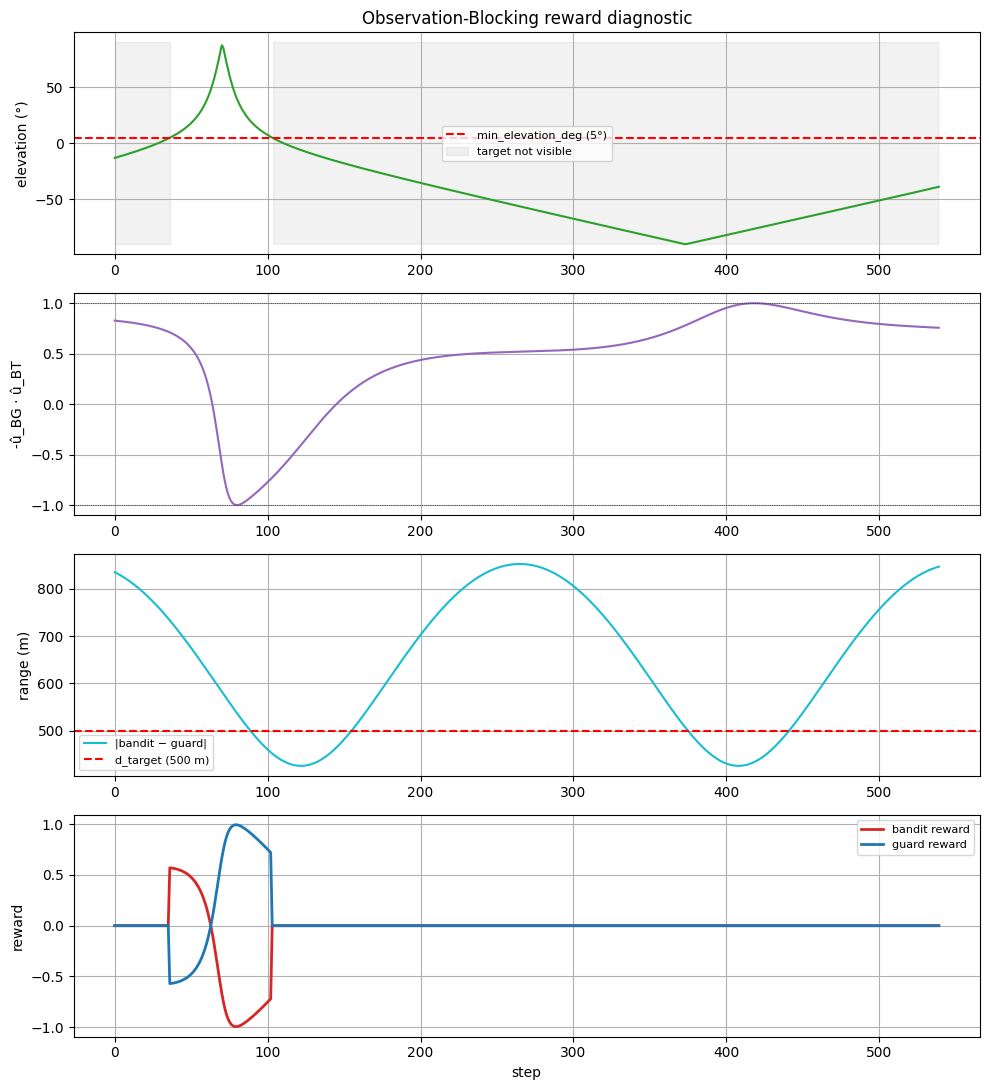

In [6]:
fig = plot_observation_blocking_diagnostic(traj1, cfg)
plt.show()

## Animated diagnostic

Three-panel animation: the 3D RTN scene on the left with the target-direction vector (gold star at `target_viewing_distance_m`); the vector switches to dashed grey when the visibility gate is closed (target below `min_elevation_deg`). Top-right shows cumulative reward over time. Bottom-right shows target elevation with the gate threshold and shaded "invisible" windows. Watch how the reward only accumulates when the elevation is above the threshold AND the bandit is in the right configuration.

In [ ]:
from IPython.display import HTML
import shutil
import pathlib

fig_anim, anim = plot_observation_blocking_animated_diagnostic(traj1, cfg, fps=15, n_frames=120)

def _repo_root() -> pathlib.Path:
    here = pathlib.Path.cwd().resolve()
    for parent in (here, *here.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    return here

if shutil.which("ffmpeg") is not None:
    out_dir = _repo_root() / "outputs"
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / "ob_animated_diagnostic.mp4"
    anim.save(str(out_path), fps=15)
    print(f"saved {out_path}  ({out_path.stat().st_size:,} bytes)")
else:
    print("ffmpeg not available — skipping MP4 export")

HTML(anim.to_jshtml(default_mode='loop'))

## 5. 2D position-sweep surface

Bandit-position sweep with guard fixed at the reference origin and target at the rotated ECI position at the chosen `t_seconds`. The cell prints `visible=True/False`; if `False`, the surface is uniformly zero by gate. We render two sweeps — one at `t_seconds=0.0` (default epoch) and one at `t_seconds=cfg.max_horizon_s/2` (mid-rollout) — to make it easy to find a visible window.

*Note: the default OB game-guide target (37.4°N, -122.2°W) is never visible from the equatorial reference orbit. This notebook uses an equatorial target (lat=0°, lon=0°) that the orbit periodically passes over — visible from roughly t=400s to t=1000s. The two sweeps below show the surface at t=0 (target below horizon, all-zero) and t=700s (mid-visibility window, peak/trough lobes appear).*

plot_observation_blocking_position_sweep: visible=False at t=0s


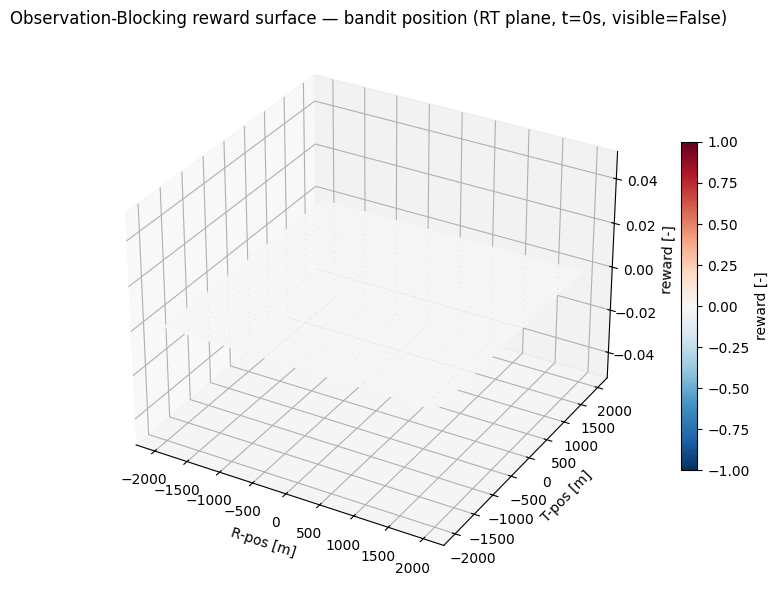

In [7]:
# Sweep at t=0
fig = plot_reward_position_sweep(cfg, grid_extent_m=2000.0, grid_steps=64, axis_pair="rt", t_seconds=0.0)
plt.show()

plot_observation_blocking_position_sweep: visible=True at t=700s


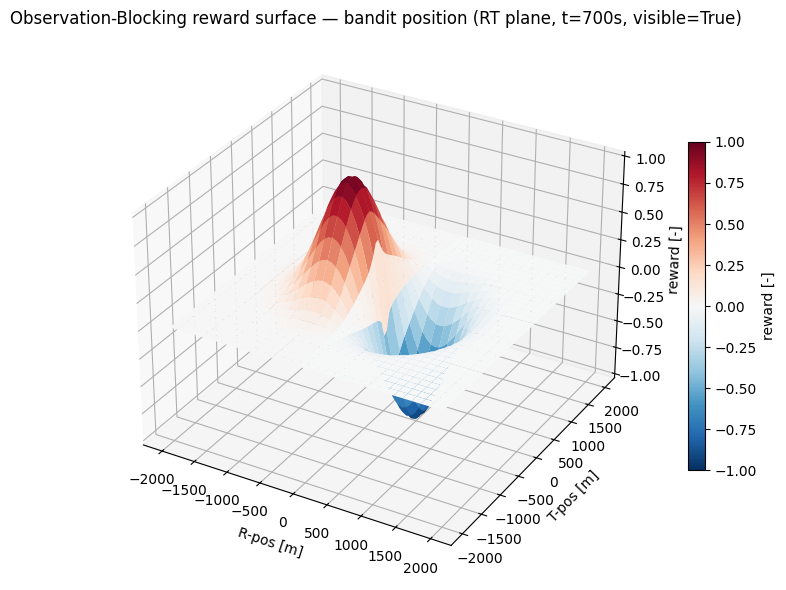

In [8]:
# Sweep at t=700s — mid-visibility-window (target visible from t≈400s to t≈1000s).
fig = plot_reward_position_sweep(cfg, grid_extent_m=2000.0, grid_steps=64, axis_pair="rt", t_seconds=700.0)
plt.show()

## 6. Where to next

- Framework deep-dive: `examples/workflow_3d_rtn.ipynb`
- Game guide: `docs/games/observation-blocking.md`
- Other games: `examples/games/lady_bandit_guard.ipynb`, `pursuit_evasion.ipynb`, `sun_blocking.ipynb`